<div style="background: linear-gradient(135deg, #1e3a8a 0%, #7c3aed 100%); padding: 30px; border-radius: 10px; color: white; margin-bottom: 20px;">
<h1 style="margin: 0; font-size: 32px;">Predicting Adverse Authorisation Outcomes for UK FCA-Regulated Firms</h1>
<h3 style="margin-top: 10px; margin-bottom: 0; font-weight: 300; opacity: 0.9;">Notebook 02: Feature Engineering</h3>
<p style="margin-top: 20px; margin-bottom: 0; font-size: 14px; opacity: 0.85;">
<b>Fannana Fahreen Aanan</b> | Student ID: 001527223<br>
MSc Data Science (FinTech) | University of Greenwich
</p>
</div>

## <span style="color: #1e3a8a;">📌 Purpose of This Notebook</span>

<div style="background-color: #f0f4f8; padding: 15px; border-left: 4px solid #1e3a8a; border-radius: 4px;">

This notebook transforms the cleaned panel (<code>firm_year_panel_clean.csv</code>) into a final feature matrix ready for modelling. Building on the findings from <code>01_EDA.ipynb</code>, four tasks are carried out:

<ol style="line-height: 1.8;">
<li><b>Log transformation</b> of the 6 heavily-skewed features, applied specifically for the logistic regression baseline</li>
<li><b>Encoding categorical variables</b> (client_money, business_type, company_type, fca_status) into a numeric format both models can use</li>
<li><b>Finalising the feature matrix</b> — deciding the exact column list, incorporating the leakage-fix decisions from EDA</li>
<li><b>Saving two versions</b> of the feature matrix: one for logistic regression (log-transformed, scaled) and one for XGBoost (raw features, since tree-based splits are invariant to monotonic transforms)</li>
</ol>

</div>

## <span style="color: #1e3a8a;">📚 Importing Libraries</span>


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

## <span style="color: #1e3a8a;">📚 Load And Inspect DATA</span>

In [4]:

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style("whitegrid")

# Load the cleaned panel (output of EDA notebook)
df = pd.read_csv("data/firm_year_panel_clean.csv")
df['obs_date'] = pd.to_datetime(df['obs_date'])
df['year'] = df['obs_date'].dt.year

print(f"Loaded: {len(df):,} rows, {len(df.columns)} columns")
print(f"Positive cases: {df['y'].sum()} ({df['y'].mean()*100:.3f}%)")
print(f"\nColumns:")
for col in df.columns:
    print(f"   {col}")

Loaded: 82,900 rows, 35 columns
Positive cases: 307 (0.370%)

Columns:
   frn
   firm_name
   obs_date
   y
   n_permissions
   client_money
   business_type
   n_prior_disciplinary
   firm_age_years
   accounts_days_late
   accounts_late_3yr_avg
   director_count
   director_churn_24m
   mean_director_tenure
   has_ch_data
   company_type
   total_filings
   has_permissions
   has_client_money
   n_active_officers
   n_total_officers
   director_to_officer_ratio
   filing_count_3yr
   has_prior_disciplinary
   fca_status
   year
   accounts_days_late_missing
   accounts_late_3yr_avg_missing
   director_churn_24m_missing
   director_count_missing
   mean_director_tenure_missing
   director_to_officer_ratio_missing
   firm_age_years_missing
   has_annual_accounts
   company_status


In [5]:
df.head()

,frn,firm_name,obs_date,y,n_permissions,client_money,business_type,n_prior_disciplinary,firm_age_years,accounts_days_late,accounts_late_3yr_avg,director_count,director_churn_24m,mean_director_tenure,has_ch_data,company_type,total_filings,has_permissions,has_client_money,n_active_officers,n_total_officers,director_to_officer_ratio,filing_count_3yr,has_prior_disciplinary,fca_status,year,accounts_days_late_missing,accounts_late_3yr_avg_missing,director_churn_24m_missing,director_count_missing,mean_director_tenure_missing,director_to_officer_ratio_missing,firm_age_years_missing,has_annual_accounts,company_status
0,120776,W1M Wealth Management Limited,2016-01-01,0,12,Not hold and not control client money,Regulated,0,29.1,0.0,0.0,2.0,0.0,10.2,1,ltd,33,1,1,2,7,1.00,7,0,Authorised,2016,0,0,0,0,1,0,0,1,active
1,120776,W1M Wealth Management Limited,2017-01-01,0,12,Not hold and not control client money,Regulated,0,30.1,0.0,0.0,1.0,1.0,10.2,1,ltd,41,1,1,1,7,1.00,11,0,Authorised,2017,0,0,0,0,1,0,0,1,active
2,120776,W1M Wealth Management Limited,2018-01-01,0,12,Not hold and not control client money,Regulated,0,31.1,0.0,0.0,1.0,1.0,10.2,1,ltd,47,1,1,1,7,1.00,16,0,Authorised,2018,0,0,0,0,1,0,0,1,active
3,120776,W1M Wealth Management Limited,2019-01-01,0,12,Not hold and not control client money,Regulated,0,32.1,0.0,0.0,1.0,0.0,10.2,1,ltd,52,1,1,1,7,1.00,19,0,Authorised,2019,0,0,0,0,1,0,0,1,active
4,120776,W1M Wealth Management Limited,2020-01-01,0,12,Not hold and not control client money,Regulated,0,33.1,0.0,0.0,5.0,1.0,0.5,1,ltd,61,1,1,6,13,0.83,20,0,Authorised,2020,0,0,0,0,0,0,0,1,active


## <span style="color: #dc2626;">🚩 Adding the n_permissions Reliability Flag</span>

<div style="background-color: #fef2f2; padding: 15px; border-left: 4px solid #dc2626; border-radius: 4px;">

As documented in the EDA notebook, <code>n_permissions</code> is partially leaky for firms whose FCA status has changed since their observation date (the FCA API provides no historical permissions data). Since <code>fca_status</code> has now been corrected to reflect point-in-time values, we use it directly to flag which rows carry this residual risk.

</div>

In [6]:
# Add the n_permissions reliability flag (planned in EDA, not yet applied)
df['n_permissions_leakage_risk'] = (df['fca_status'] != 'Authorised').astype(int)

print("n_permissions_leakage_risk distribution:")
print(df['n_permissions_leakage_risk'].value_counts())
print(f"\nPercentage flagged as at-risk: {df['n_permissions_leakage_risk'].mean()*100:.1f}%")

n_permissions_leakage_risk distribution:
n_permissions_leakage_risk
0    71641
1    11259
Name: count, dtype: int64

Percentage flagged as at-risk: 13.6%


## <span style="color: #f59e0b;">📐 Log Transformation for Skewed Features</span>

<div style="background-color: #fef3c7; padding: 15px; border-left: 4px solid #f59e0b; border-radius: 4px;">

Six features were identified in EDA as heavily right-skewed (skew > 3): <code>accounts_days_late</code>, <code>accounts_late_3yr_avg</code>, <code>n_prior_disciplinary</code>, <code>n_active_officers</code>, <code>director_churn_24m</code>, and <code>firm_age_years</code>.

Log transformation (<code>log1p</code>, i.e. log(1+x)) compresses extreme outliers and reduces skewness, which helps stabilise the coefficient estimates in the L2-regularised logistic regression baseline. <code>log1p</code> is used instead of a plain log because several features contain zeros, and log(0) is undefined — log1p(0) = 0, handling this safely.

This transformation is applied to create <b>new columns</b> (suffixed <code>_log</code>), leaving the original columns intact. XGBoost will use the original, untransformed columns, since tree-based splits are invariant to monotonic transformations such as log — applying it would not change how XGBoost partitions the data, only how logistic regression fits its linear coefficients.

</div>

In [16]:
print("Checking firm_age_years for problematic values:\n")
print(f"Minimum value: {df['firm_age_years'].min()}")
print(f"Maximum value: {df['firm_age_years'].max()}")
print(f"\nCount of values < 0:  {(df['firm_age_years'] < 0).sum()}")
print(f"Count of values == -1: {(df['firm_age_years'] == -1).sum()}")
print(f"Count of values <= -1: {(df['firm_age_years'] <= -1).sum()}")

# Check the log column directly for -inf and nan
print(f"\nfirm_age_years_log diagnostics:")
print(f"Count of -inf: {np.isneginf(df['firm_age_years_log']).sum()}")
print(f"Count of nan:  {df['firm_age_years_log'].isna().sum()}")

# Show the problematic rows
problem_rows = df[(df['firm_age_years'] <= -1) | (df['firm_age_years'].isna())]
print(f"\nSample of problematic rows ({len(problem_rows)} total):")
print(problem_rows[['frn', 'firm_name', 'obs_date', 'firm_age_years']].head(10))

Checking firm_age_years for problematic values:

Minimum value: 0.0
Maximum value: 159.9

Count of values < 0:  0
Count of values == -1: 0
Count of values <= -1: 0

firm_age_years_log diagnostics:
Count of -inf: 0
Count of nan:  0

Sample of problematic rows (0 total):
Empty DataFrame
Columns: [frn, firm_name, obs_date, firm_age_years]
Index: []


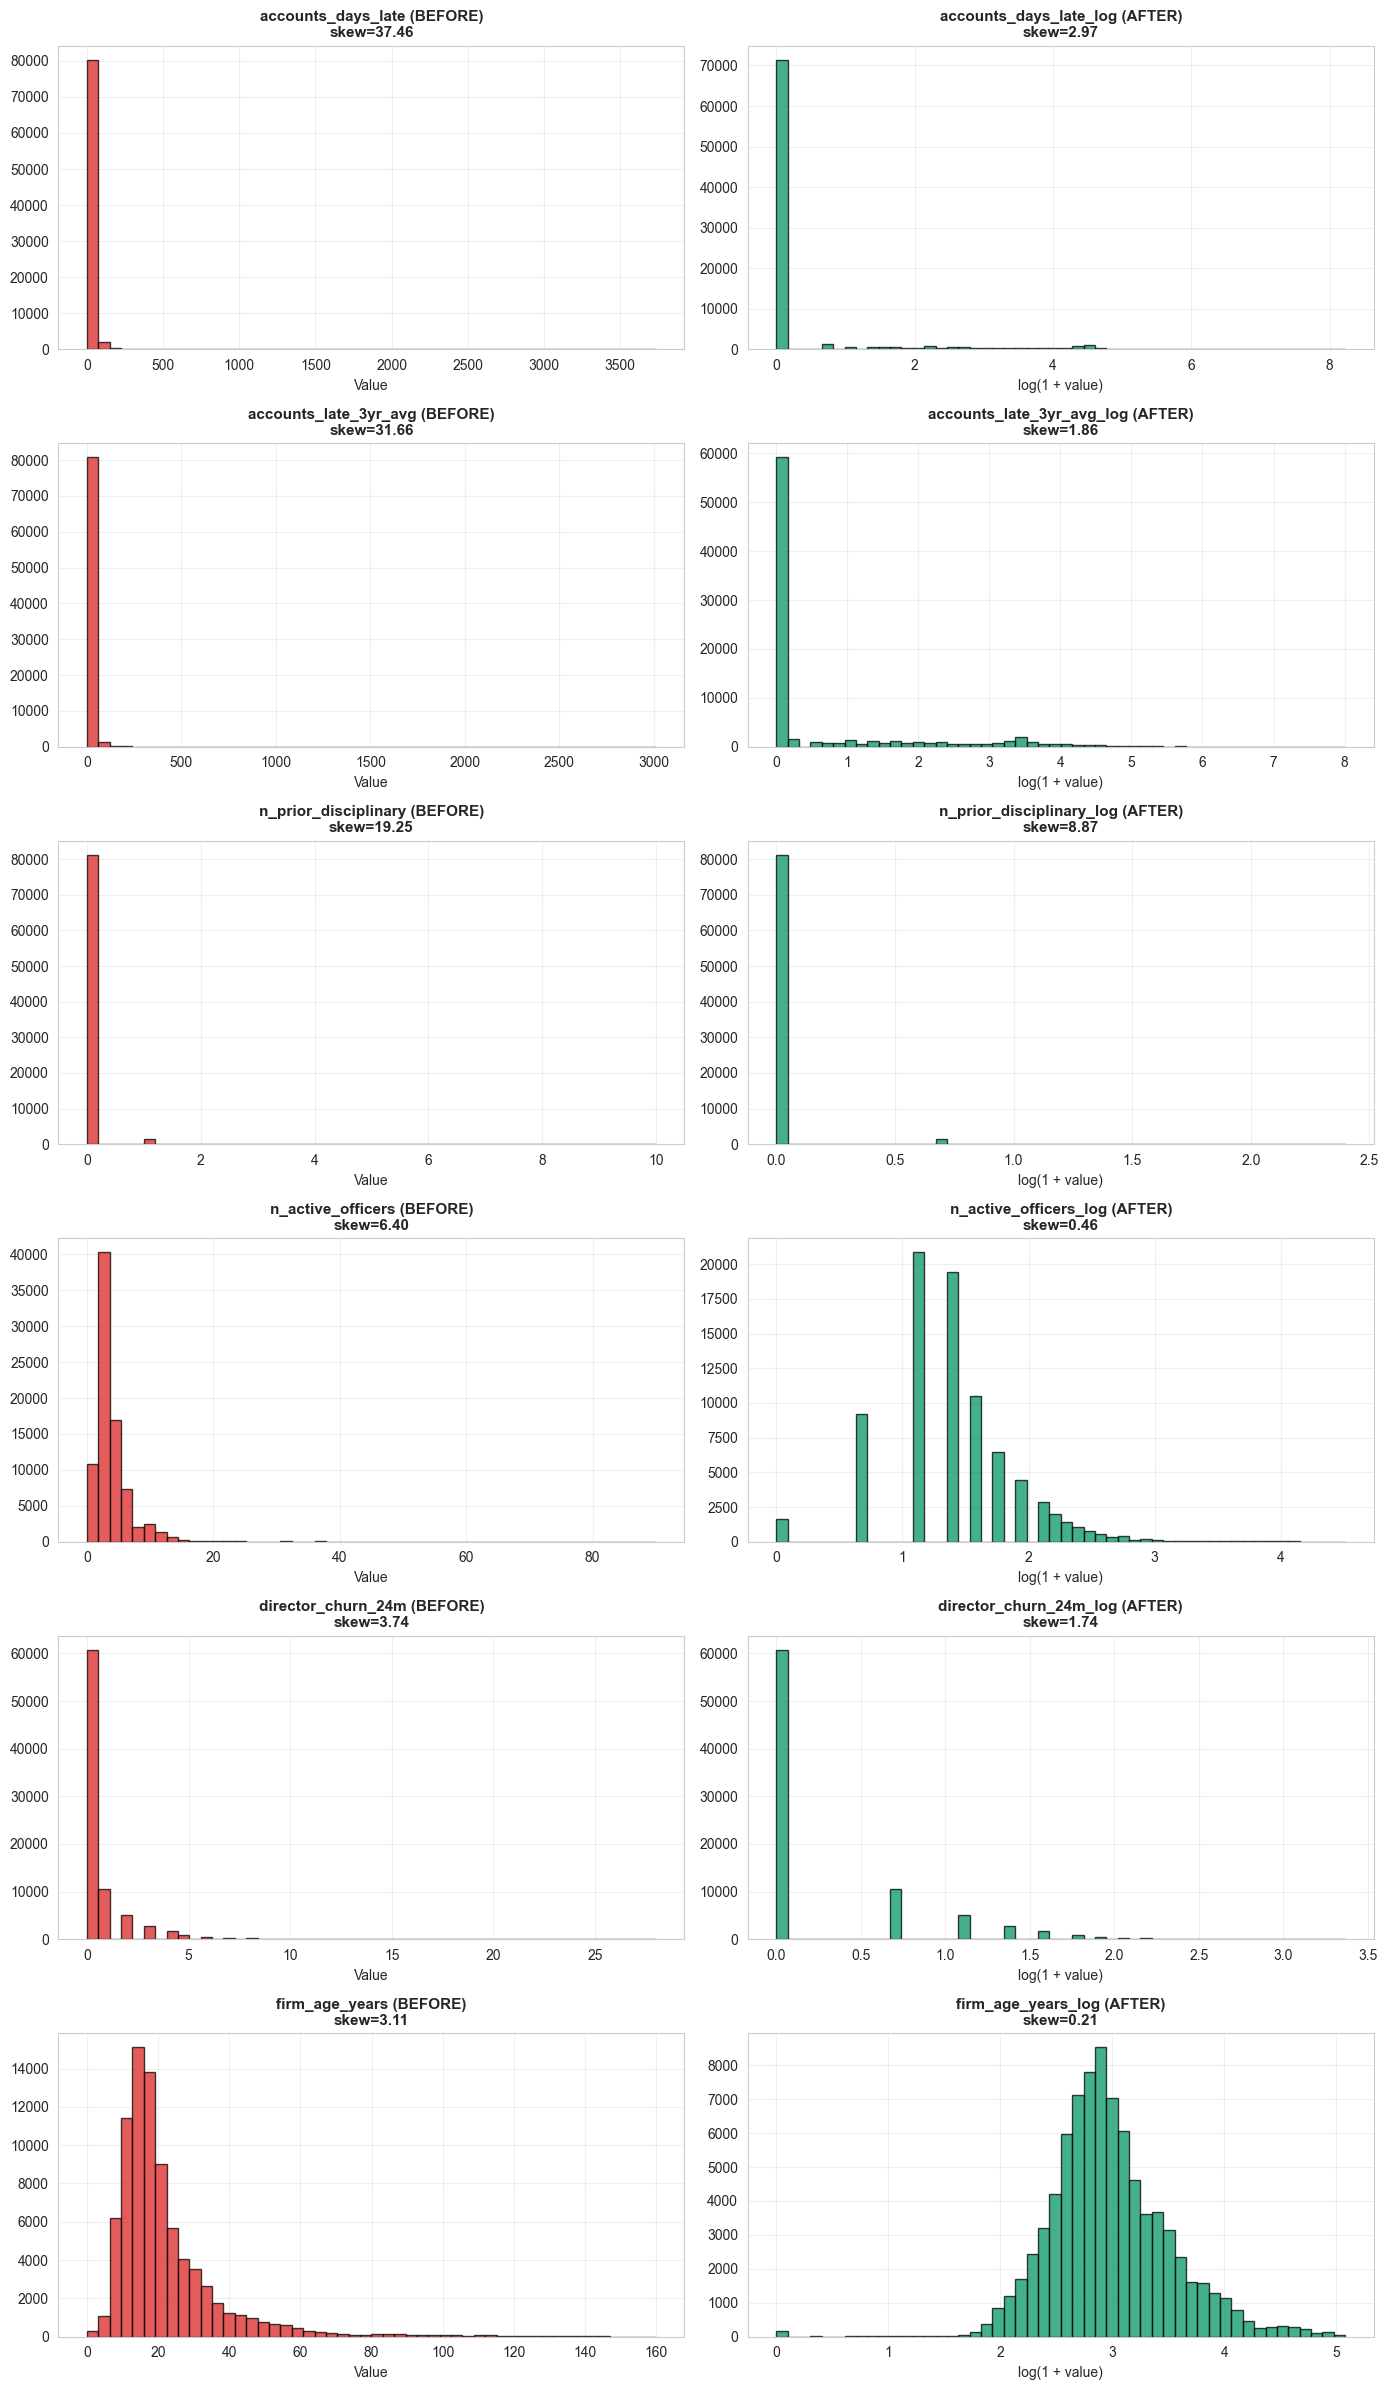


FINAL SKEWNESS SUMMARY (all 6 features):
   accounts_days_late          37.46 ->    2.97
   accounts_late_3yr_avg       31.66 ->    1.86
   n_prior_disciplinary        19.25 ->    8.87
   n_active_officers            6.40 ->    0.46
   director_churn_24m           3.74 ->    1.74
   firm_age_years               3.11 ->    0.21


In [19]:
fig, axes = plt.subplots(6, 2, figsize=(14, 24))

for i, col in enumerate(skewed_features):
    log_col = f'{col}_log'
    
    # BEFORE (original scale)
    ax1 = axes[i, 0]
    ax1.hist(df[col], bins=50, color='#dc2626', alpha=0.75, edgecolor='black')
    ax1.set_title(f'{col} (BEFORE)\nskew={df[col].skew():.2f}', fontsize=11, fontweight='bold')
    ax1.set_xlabel('Value')
    ax1.grid(alpha=0.3)
    
    # AFTER (log scale)
    ax2 = axes[i, 1]
    ax2.hist(df[log_col], bins=50, color='#059669', alpha=0.75, edgecolor='black')
    ax2.set_title(f'{log_col} (AFTER)\nskew={df[log_col].skew():.2f}', fontsize=11, fontweight='bold')
    ax2.set_xlabel('log(1 + value)')
    ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nFINAL SKEWNESS SUMMARY (all 6 features):")
for col in skewed_features:
    print(f"   {col:25s} {df[col].skew():>7.2f} -> {df[f'{col}_log'].skew():>7.2f}")

## <span style="color: #059669;">📊 Log Transformation Results: Before vs After</span>

<div style="background-color: #f0fdf4; padding: 15px; border-left: 4px solid #059669; border-radius: 4px;">

The 12-panel comparison confirms the log transformation was effective across the six heavily skewed features, with varying degrees of success depending on the underlying data shape:

<b>Strong improvements (visually now much closer to symmetric):</b>
<ul style="line-height: 1.8;">
<li><code>firm_age_years</code> (3.10 → 0.21) — the clearest success; the transformed distribution now resembles a smooth bell shape, helped by clipping the small number of negative ages to zero beforehand</li>
<li><code>accounts_days_late</code> (37.46 → 2.97) and <code>accounts_late_3yr_avg</code> (31.66 → 1.86) — both go from an extreme spike-and-tail shape to a much more manageable distribution, though a residual spike at zero remains, reflecting the large share of firms that filed exactly on time</li>
<li><code>n_active_officers</code> (6.40 → 0.46) — transforms into a distribution with a visible peak and gradual taper, a substantial improvement over the original heavily front-loaded shape</li>
</ul>

<b>Partial improvement (still noticeably skewed):</b>
<ul style="line-height: 1.8;">
<li><code>director_churn_24m</code> (3.74 → 1.74) — improved but retains a step-like pattern, since churn is a small integer count with limited possible values</li>
<li><code>n_prior_disciplinary</code> (19.25 → 8.87) — barely changes visually, since over 99% of firms have a value of exactly zero; log transformation has little to compress when the distribution is this concentrated at a single point rather than spread across a long tail</li>
</ul>

<b>Interpretation:</b> the two features that improved the least (<code>director_churn_24m</code> and <code>n_prior_disciplinary</code>) are not a cause for concern — both were already established during EDA as strong predictors precisely <i>because</i> of their concentration at zero with a small number of highly informative non-zero values. Log transformation's job is to help the logistic regression baseline handle extreme outliers gracefully; it does not need to (and cannot) turn a naturally rare, spike-shaped feature into a bell curve. The log-transformed versions will be used only for the logistic regression model, while XGBoost will continue to use the original, untransformed features.

</div>

## <span style="color: #7c3aed;">🔤 Encoding Categorical Variables</span>

<div style="background-color: #f5f3ff; padding: 15px; border-left: 4px solid #7c3aed; border-radius: 4px;">

Four categorical features need to be converted into numeric form before modelling: <code>client_money</code>, <code>business_type</code>, <code>company_type</code>, and <code>fca_status</code>.

<b>One-hot encoding</b> is used, which creates a new binary (0/1) column for each category. This is required for logistic regression, which can only work with numeric inputs, and is also compatible with XGBoost.

To avoid creating excessive sparse columns from rare categories, categories representing fewer than 50 observations are grouped into an "Other" bucket before encoding, consistent with the 50+ observation threshold used throughout the EDA categorical analysis.

</div>

In [20]:
categorical_features = ['client_money', 'business_type', 'company_type', 'fca_status']

print("Category counts before grouping rare categories:\n")
for col in categorical_features:
    print(f"{col}: {df[col].nunique()} unique categories")

# Group rare categories (< 50 observations) into "Other"
df_encoded = df.copy()

for col in categorical_features:
    counts = df_encoded[col].value_counts()
    rare_categories = counts[counts < 50].index.tolist()
    if rare_categories:
        df_encoded[col] = df_encoded[col].replace(rare_categories, 'Other')
        print(f"\n{col}: grouped {len(rare_categories)} rare categories into 'Other'")
        print(f"   Rare categories were: {rare_categories}")

print("\nCategory counts after grouping:")
for col in categorical_features:
    print(f"\n{col}:")
    print(df_encoded[col].value_counts())

# One-hot encode
df_encoded = pd.get_dummies(df_encoded, columns=categorical_features, prefix=categorical_features, drop_first=False)

print(f"\n\nColumns before encoding: {len(df.columns)}")
print(f"Columns after encoding: {len(df_encoded.columns)}")

new_dummy_cols = [c for c in df_encoded.columns if any(c.startswith(f'{cat}_') for cat in categorical_features)]
print(f"\nNew one-hot encoded columns ({len(new_dummy_cols)}):")
for c in new_dummy_cols:
    print(f"   {c}")

Category counts before grouping rare categories:

client_money: 4 unique categories
business_type: 10 unique categories
company_type: 17 unique categories
fca_status: 7 unique categories

business_type: grouped 4 rare categories into 'Other'
   Rare categories were: ['Services (UK) of an Overseas Firm', 'Exchange', 'Trustee/Depositary', 'Operator']

company_type: grouped 5 rare categories into 'Other'
   Rare categories were: ['assurance-company', 'converted-or-closed', 'registered-overseas-entity', 'european-public-limited-liability-company-se', 'private-unlimited-nsc']

fca_status: grouped 3 rare categories into 'Other'
   Rare categories were: ['EEA Authorised', 'Recognised', 'Authorised Schedule 5']

Category counts after grouping:

client_money:
client_money
Not hold and not control client money    37584
Missing                                  27415
Hold and control client money            12654
Control but not hold client money         5247
Name: count, dtype: int64

business_ty

In [21]:
print("Checking if grouped categories had meaningfully different risk profiles:\n")

for col, rare_list in [
    ('business_type', ['Services (UK) of an Overseas Firm', 'Exchange', 'Trustee/Depositary', 'Operator']),
    ('company_type', ['assurance-company', 'converted-or-closed', 'registered-overseas-entity', 
                       'european-public-limited-liability-company-se', 'private-unlimited-nsc']),
    ('fca_status', ['EEA Authorised', 'Recognised', 'Authorised Schedule 5'])
]:
    print(f"\n{col} - individual rare category rates:")
    for cat in rare_list:
        subset = df[df[col] == cat]
        if len(subset) > 0:
            rate = subset['y'].mean() * 100
            print(f"   {cat:50s} n={len(subset):>4}  rate={rate:.2f}%")

Checking if grouped categories had meaningfully different risk profiles:


business_type - individual rare category rates:
   Services (UK) of an Overseas Firm                  n=  47  rate=0.00%
   Exchange                                           n=  36  rate=2.78%
   Trustee/Depositary                                 n=  13  rate=0.00%
   Operator                                           n=   8  rate=0.00%

company_type - individual rare category rates:
   assurance-company                                  n=  49  rate=0.00%
   converted-or-closed                                n=  35  rate=0.00%
   registered-overseas-entity                         n=  18  rate=0.00%
   european-public-limited-liability-company-se       n=  12  rate=16.67%
   private-unlimited-nsc                              n=   2  rate=0.00%

fca_status - individual rare category rates:
   EEA Authorised                                     n=  45  rate=0.00%
   Recognised                                       

## <span style="color: #1e3a8a;">🎯 Finalizing the Feature Matrix</span>

<div style="background-color: #f0f4f8; padding: 15px; border-left: 4px solid #1e3a8a; border-radius: 4px;">

With log transforms and categorical encoding complete, this step assembles the final feature matrix for modelling. Two versions are created:

<ul style="line-height: 1.8;">
<li><b>Logistic regression version</b> — uses log-transformed features for the 6 heavily-skewed variables, plus one-hot encoded categoricals</li>
<li><b>XGBoost version</b> — uses the original, untransformed numeric features, plus one-hot encoded categoricals (tree splits are invariant to monotonic transforms, so log transformation provides no benefit)</li>
</ul>

Identifier columns (<code>frn</code>, <code>firm_name</code>, <code>obs_date</code>, <code>year</code>) and the original pre-encoding categorical text columns are excluded from both matrices, since they are either non-numeric or not intended as model inputs.

</div>

In [22]:
# Identify all column groups
id_cols = ['frn', 'firm_name', 'obs_date', 'year']
label_col = 'y'

log_transformed_originals = ['accounts_days_late', 'accounts_late_3yr_avg', 'n_prior_disciplinary',
                              'n_active_officers', 'director_churn_24m', 'firm_age_years']
log_cols = [f'{c}_log' for c in log_transformed_originals]

# Flag columns (missingness indicators + leakage risk)
flag_cols = [c for c in df_encoded.columns if c.endswith('_missing') or c == 'n_permissions_leakage_risk']

# One-hot encoded categorical columns
onehot_cols = [c for c in df_encoded.columns if any(
    c.startswith(f'{cat}_') for cat in ['client_money', 'business_type', 'company_type', 'fca_status']
)]

# Other numeric features (not log-transformed, not flags, not onehot)
other_numeric = ['n_permissions', 'director_count', 'mean_director_tenure', 'has_ch_data',
                  'total_filings', 'has_permissions', 'has_client_money', 'n_total_officers',
                  'director_to_officer_ratio', 'filing_count_3yr', 'has_prior_disciplinary',
                  'has_annual_accounts']

print("Column group sizes:")
print(f"   ID columns:              {len(id_cols)}")
print(f"   Log-transformed originals: {len(log_transformed_originals)}")
print(f"   Log columns:              {len(log_cols)}")
print(f"   Flag columns:             {len(flag_cols)}")
print(f"   One-hot columns:          {len(onehot_cols)}")
print(f"   Other numeric:            {len(other_numeric)}")

# ============ BUILD LOGISTIC REGRESSION FEATURE SET ============
# Uses log-transformed versions instead of the originals
logistic_features = other_numeric + log_cols + flag_cols + onehot_cols
X_logistic = df_encoded[logistic_features].copy()

# ============ BUILD XGBOOST FEATURE SET ============
# Uses original untransformed versions
xgboost_features = other_numeric + log_transformed_originals + flag_cols + onehot_cols
X_xgboost = df_encoded[xgboost_features].copy()

# Labels and identifiers (kept separately)
y = df_encoded[label_col].copy()
ids = df_encoded[id_cols].copy()

print(f"\nFinal feature matrix shapes:")
print(f"   Logistic regression: {X_logistic.shape}")
print(f"   XGBoost:              {X_xgboost.shape}")
print(f"   Label (y):            {y.shape}")

print(f"\nAny remaining nulls in X_logistic? {X_logistic.isnull().sum().sum()}")
print(f"Any remaining nulls in X_xgboost?  {X_xgboost.isnull().sum().sum()}")

print(f"\nData types check (all should be numeric):")
print(f"   X_logistic non-numeric columns: {X_logistic.select_dtypes(exclude=[np.number, bool]).columns.tolist()}")
print(f"   X_xgboost non-numeric columns:  {X_xgboost.select_dtypes(exclude=[np.number, bool]).columns.tolist()}")

Column group sizes:
   ID columns:              4
   Log-transformed originals: 6
   Log columns:              6
   Flag columns:             8
   One-hot columns:          29
   Other numeric:            12

Final feature matrix shapes:
   Logistic regression: (82900, 55)
   XGBoost:              (82900, 55)
   Label (y):            (82900,)

Any remaining nulls in X_logistic? 0
Any remaining nulls in X_xgboost?  0

Data types check (all should be numeric):
   X_logistic non-numeric columns: []
   X_xgboost non-numeric columns:  []


## <span style="color: #059669;">💾 Saving the Final Feature Matrices</span>

<div style="background-color: #f0fdf4; padding: 15px; border-left: 4px solid #059669; border-radius: 4px;">

Three files are saved to complete this notebook:

<ul style="line-height: 1.8;">
<li><b>X_logistic.csv</b> — 55 features (log-transformed) for the logistic regression baseline</li>
<li><b>X_xgboost.csv</b> — 55 features (raw) for the XGBoost model</li>
<li><b>y_and_ids.csv</b> — the label and identifier columns (frn, firm_name, obs_date, year), kept separate so both feature matrices stay purely numeric</li>
</ul>

These three files, always joined by row position (or by re-merging on frn + obs_date if needed), form the complete input to the Modelling notebook.

</div>

In [23]:
Path("data").mkdir(exist_ok=True)

# Save all three pieces
X_logistic.to_csv("data/X_logistic.csv", index=False)
X_xgboost.to_csv("data/X_xgboost.csv", index=False)

y_and_ids = pd.concat([ids.reset_index(drop=True), y.reset_index(drop=True)], axis=1)
y_and_ids.to_csv("data/y_and_ids.csv", index=False)

print("Saved:")
print(f"   data/X_logistic.csv   - {X_logistic.shape}")
print(f"   data/X_xgboost.csv    - {X_xgboost.shape}")
print(f"   data/y_and_ids.csv    - {y_and_ids.shape}")

print(f"\nSanity check - row alignment:")
print(f"   X_logistic rows: {len(X_logistic)}")
print(f"   X_xgboost rows:  {len(X_xgboost)}")
print(f"   y_and_ids rows:  {len(y_and_ids)}")
print(f"   All match: {len(X_logistic) == len(X_xgboost) == len(y_and_ids)}")

print(f"\nPositive cases in saved y: {y_and_ids['y'].sum()}")
print(f"Years covered: {sorted(y_and_ids['year'].unique())}")

Saved:
   data/X_logistic.csv   - (82900, 55)
   data/X_xgboost.csv    - (82900, 55)
   data/y_and_ids.csv    - (82900, 5)

Sanity check - row alignment:
   X_logistic rows: 82900
   X_xgboost rows:  82900
   y_and_ids rows:  82900
   All match: True

Positive cases in saved y: 307
Years covered: [np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024)]


In [2]:
# Check specifically: does X_logistic contain the RAW (non-log) versions too?
raw_feature_names = ['accounts_days_late', 'accounts_late_3yr_avg', 'n_prior_disciplinary',
                      'n_active_officers', 'director_churn_24m', 'firm_age_years']

print("Checking X_logistic.csv for these EXACT raw column names:\n")
for col in raw_feature_names:
    present = col in X_logistic.columns
    print(f"   {col:30s} in X_logistic? {present}")

print("\nChecking X_xgboost.csv for the LOG column names:\n")
log_feature_names = [f'{c}_log' for c in raw_feature_names]
for col in log_feature_names:
    present = col in X_xgboost.columns
    print(f"   {col:30s} in X_xgboost? {present}")

Checking X_logistic.csv for these EXACT raw column names:

   accounts_days_late             in X_logistic? False
   accounts_late_3yr_avg          in X_logistic? False
   n_prior_disciplinary           in X_logistic? False
   n_active_officers              in X_logistic? False
   director_churn_24m             in X_logistic? False
   firm_age_years                 in X_logistic? False

Checking X_xgboost.csv for the LOG column names:

   accounts_days_late_log         in X_xgboost? False
   accounts_late_3yr_avg_log      in X_xgboost? False
   n_prior_disciplinary_log       in X_xgboost? False
   n_active_officers_log          in X_xgboost? False
   director_churn_24m_log         in X_xgboost? False
   firm_age_years_log             in X_xgboost? False
